# AI651 PA1 — Task 2: Leaderboard Challenge (Autoformer)

**Goal.** Forecast the next 168 steps (`time_idx` 43,657–43,824) of an anonymised univariate series with an Autoformer, and test whether the optional external file helps.

**Pipeline at a glance**
1. Data and periodicity → the series is hourly-like, with a weak 24-step and a ~8,766-step cycle.
2. Chronological split: train | early-stop (12 weeks) | evaluation (24 non-overlapping 168-step blocks).
3. Naive baselines on the same 24 blocks.
4. A small Autoformer (~22k parameters) with Auto-Correlation and progressive series decomposition.
5. External-data ablation: `none` vs `past` (encoder only) vs `pastfuture` (encoder + decoder over the horizon), 3 seeds each.
6. The final forecast and the leaderboard string, with P and E.

**Code provenance.** `autoformer/AutoCorrelation.py` and `autoformer/Autoformer_EncDec.py` are copied from the official Autoformer repository (thuml, MIT licence) and cited in their headers. Everything else in this notebook (the embedding, model wiring, data handling, validation, experiments) is written here. `task2.py` contains the same code as these cells. It is the command-line entry point used to run the 9 seed runs in parallel (`python task2.py run --variant pastfuture --seed 0`).

In [ ]:
import json, math, os, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Auto-Correlation + series decomposition blocks, copied (with citation) from the
# official implementation: github.com/thuml/Autoformer (MIT), Wu et al. NeurIPS 2021.
from autoformer.AutoCorrelation import AutoCorrelation, AutoCorrelationLayer
from autoformer.Autoformer_EncDec import (Encoder, Decoder, EncoderLayer, DecoderLayer,
                                          my_Layernorm, series_decomp)

HERE = os.path.abspath("")
DATA = os.path.join(HERE, "Data")
RES = os.path.join(HERE, "results")
FIG = os.path.join(HERE, "figures"); os.makedirs(FIG, exist_ok=True)
torch.set_num_threads(max(1, os.cpu_count() // 2))

# True : retrain all 9 runs from scratch (roughly 1 min per epoch per run on CPU; ~45-60 min total).
# False: load the per-seed results already saved in results/runs (takes seconds).
RUN_EXPERIMENTS = True

## 1. Configuration and chronological split
Every reported number comes from the **evaluation** region, and that region is never used for training or for early stopping. The early-stop region only decides which epoch to keep. Each evaluation block has the same shape as one leaderboard submission (168 steps), so averaging over 24 of them gives a far more reliable estimate than any single block.

In [ ]:
SEQ_LEN, LABEL_LEN, PRED_LEN = 168, 48, 168
N_HIST = 43656                      # observed history length
N_EVAL_BLOCKS, N_ES_BLOCKS = 24, 12  # non-overlapping 168-step blocks
EVAL_START = N_HIST - N_EVAL_BLOCKS * PRED_LEN     # 39624
ES_START = EVAL_START - N_ES_BLOCKS * PRED_LEN     # 37608  (training targets end here)
PERIODS = (24.0, 8766.0)             # recovered from the periodogram (daily, yearly)

MODEL_CFG = dict(d_model=32, n_heads=4, e_layers=1, d_layers=1, d_ff=64,
                 moving_avg=25, factor=1, dropout=0.1, exo_head=True)
TRAIN_CFG = dict(batch=64, lr=3e-4, exo_lr=1e-2, max_epochs=10, patience=3, train_stride=2)

CONT = ["feature_A", "feature_B", "feature_C", "feature_D", "feature_E", "feature_F"]
BIN = ["feature_G", "feature_H", "feature_I", "feature_J"]
LOG_COLS = ["feature_D", "feature_E", "feature_F"]   # heavy-tailed cumulative counters

## 2. Data
Phase features replace the missing calendar: sin/cos of 2πt/24 and 2πt/8766, using periods **measured** from the periodogram below. External covariates: D, E and F are heavy-tailed cumulative counters, so they get `log1p`. The six continuous features are standardised with training-region statistics, and the four mutually exclusive binary flags are left as 0/1.

`marks_for` defines the three ablation variants: what the encoder sees vs what the decoder sees.

In [ ]:
def load():
    y = pd.read_csv(os.path.join(DATA, "student_train.csv"))["value"].to_numpy(float)
    X = pd.read_csv(os.path.join(DATA, "optional_external_data.csv"))
    assert len(y) == N_HIST and len(X) == N_HIST + PRED_LEN
    t = X["time_idx"].to_numpy(float)
    phase = np.concatenate([np.stack([np.sin(2 * np.pi * t / p), np.cos(2 * np.pi * t / p)], 1)
                            for p in PERIODS], 1)
    cov = X[CONT + BIN].copy()
    for c in LOG_COLS:
        cov[c] = np.log1p(cov[c])
    cov = cov.to_numpy(float)
    mu, sd = cov[:ES_START].mean(0), cov[:ES_START].std(0) + 1e-8
    mu[len(CONT):], sd[len(CONT):] = 0.0, 1.0          # leave one-hot columns as 0/1
    cov = (cov - mu) / sd
    return y, phase.astype(np.float32), cov.astype(np.float32)


def marks_for(variant, phase, cov):
    """Return (encoder marks, decoder marks) arrays over the full 43,824-step clock."""
    if variant == "none":
        return phase, phase
    if variant == "past":            # covariates only up to the forecast origin
        return np.concatenate([phase, cov], 1), phase
    if variant == "pastfuture":      # covariates also across the forecast horizon
        both = np.concatenate([phase, cov], 1)
        return both, both
    raise ValueError(variant)


class Scaler:
    def __init__(self, y):
        self.m, self.s = float(y[:ES_START].mean()), float(y[:ES_START].std())
    def f(self, v): return (v - self.m) / self.s
    def inv(self, v): return v * self.s + self.m


def make_batch(origins, ys, menc, mdec):
    """origin o = index of the first forecast step (0-based)."""
    xe = np.stack([ys[o - SEQ_LEN:o] for o in origins])[..., None]
    me = np.stack([menc[o - SEQ_LEN:o] for o in origins])
    md = np.stack([mdec[o - LABEL_LEN:o + PRED_LEN] for o in origins])
    return torch.tensor(xe), torch.tensor(me), torch.tensor(md)


def target(origins, ys):
    return torch.tensor(np.stack([ys[o:o + PRED_LEN] for o in origins])[..., None])

In [ ]:
y, phase, cov = load()
X = pd.read_csv(os.path.join(DATA, "optional_external_data.csv"))
print("history:", y.shape, " covariates over history + horizon:", cov.shape)
print(pd.Series(y).describe().round(1).to_dict())

fig, ax = plt.subplots(2, 1, figsize=(11, 5))
ax[0].plot(np.arange(1, len(y) + 1), y, lw=0.3)
for s, c in [(ES_START, "orange"), (EVAL_START, "red")]:
    ax[0].axvline(s, color=c, ls="--")
ax[0].set_title("Full history (orange: early-stop region starts, red: evaluation region starts)")
ax[1].plot(np.arange(len(y) - 24 * 28, len(y)) + 1, y[-24 * 28:], lw=0.8)
ax[1].set_title("Last 4 weeks"); ax[1].set_xlabel("time_idx")
plt.tight_layout(); plt.savefig(f"{FIG}/2.1-series.pdf"); plt.show()

### Periodicity (no calendar is given, so the period has to be recovered)
The periodogram peaks at 24 and near 8,730 steps (≈ 8,766), which points to hourly sampling with a daily and a yearly cycle. The autocorrelation is strong at short lags but decays fast. That matches the PDF's warning and explains why persistence is a poor 168-step forecaster.

In [ ]:
z = y - y.mean()
P = np.abs(np.fft.rfft(z)) ** 2; f = np.fft.rfftfreq(len(z))
top = np.argsort(P[1:])[::-1][:8] + 1
print("Top periodogram periods:", [round(1 / f[i], 1) for i in top])
lags = np.arange(0, 24 * 15)
acf = np.array([1.0] + [np.corrcoef(z[:-l], z[l:])[0, 1] for l in lags[1:]])
print("ACF at lags 1, 6, 24, 48, 168:", acf[[1, 6, 24, 48, 168]].round(3))
prof = pd.Series(y).groupby(np.arange(len(y)) % 24).mean()

fig, ax = plt.subplots(1, 3, figsize=(13, 3.3))
per = 1 / f[1:]; m = (per > 2) & (per < 20000)
ax[0].loglog(per[m], P[1:][m], lw=0.5); ax[0].set_xlabel("period (steps)"); ax[0].set_title("Periodogram")
for p in (24, 168, 8766): ax[0].axvline(p, color="r", ls=":", lw=0.8)
ax[1].plot(lags, acf); ax[1].axhline(0, c="k", lw=0.5); ax[1].set_xlabel("lag"); ax[1].set_title("ACF")
ax[2].bar(prof.index, prof.values); ax[2].set_xlabel("t mod 24"); ax[2].set_title("Mean by phase of the 24-step cycle")
plt.tight_layout(); plt.savefig(f"{FIG}/2.2-periodicity.pdf"); plt.show()

### External covariates: first look
The correlations with the target are weak in level and almost zero in first differences. On their own they say little, so the real test is the ablation in Section 6.

In [ ]:
Xh = X.iloc[:N_HIST]
tab = pd.DataFrame({c: {"corr(level)": np.corrcoef(Xh[c], y)[0, 1],
                        "corr(diff)": np.corrcoef(np.diff(Xh[c]), np.diff(y))[0, 1]}
                    for c in CONT + BIN}).T.round(3)
print("binary flags sum to 1 at every step:", bool((X[BIN].sum(axis=1) == 1).all()))
tab

## 3. Metrics and naive baselines
Metrics are computed **per 168-step block** and then averaged over the 24 evaluation blocks, matching the leaderboard's unit of scoring. MAE, RMSE and sMAPE are all tracked. RMSE punishes the large spikes in this heavy-tailed series, while sMAPE is dominated by the low-value periods.

In [ ]:
def metrics(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    d = np.abs(y - p)
    smape = np.mean(np.where((np.abs(y) + np.abs(p)) > 0, 200 * d / (np.abs(y) + np.abs(p) + 1e-12), 0.0))
    return dict(MAE=float(d.mean()), RMSE=float(np.sqrt(np.mean(d ** 2))), sMAPE=float(smape))


def block_metrics(preds, y, origins):
    """Mean over 168-step blocks of the per-block metric (each block = one leaderboard-like score)."""
    rows = [metrics(y[o:o + PRED_LEN], p) for o, p in zip(origins, preds)]
    return {k: float(np.mean([r[k] for r in rows])) for k in rows[0]}, rows


EVAL_ORIGINS = [EVAL_START + k * PRED_LEN for k in range(N_EVAL_BLOCKS)]

In [ ]:
def baselines():
    y, _, _ = load()
    train_mean = y[:ES_START].mean()
    fc = {
        "Persistence (last value)": lambda o: np.full(PRED_LEN, y[o - 1]),
        "Mean of last 168": lambda o: np.full(PRED_LEN, y[o - 168:o].mean()),
        "Seasonal naive (24)": lambda o: np.tile(y[o - 24:o], 7),
        "Training mean": lambda o: np.full(PRED_LEN, train_mean),
    }
    out = {}
    for name, f in fc.items():
        agg, rows = block_metrics([f(o) for o in EVAL_ORIGINS], y, EVAL_ORIGINS)
        out[name] = dict(agg, blocks=rows)
        print(f"{name:28s} " + "  ".join(f"{k}={v:8.2f}" for k, v in agg.items()))
    os.makedirs(RES, exist_ok=True)
    json.dump(out, open(os.path.join(RES, "baselines.json"), "w"), indent=1)

baselines()

A flat line at the training mean beats persistence by a wide margin over 168 steps. Any model has to beat roughly **RMSE ≈ 83** to justify its parameters.

## 4. Model: Autoformer
The wiring follows the reference `models/Autoformer.py`:
* **Series decomposition**: the input is split into a seasonal part and a trend (moving average, kernel 25). The decoder's trend is initialised with the last `label_len` trend values plus the window mean, and its seasonal part with zeros. Every encoder and decoder block decomposes again after Auto-Correlation and after the feed-forward layer, and the extracted trends are accumulated into the output.
* **Auto-Correlation**: in place of dot-product attention, each layer computes series-wise autocorrelation via FFT, keeps the top k = ⌊c·ln L⌋ delays (c = `factor` = 1), and aggregates time-rolled copies weighted by softmaxed correlations. It is used for encoder self-attention, decoder self-attention and cross-attention.
* **Exogenous linear head (added here)**: a per-step linear map from the decoder marks over the horizon straight to the output, added to the seasonal + trend output. Auto-Correlation aggregates time-shifted copies of the whole sequence, which smears a covariate effect that acts at one specific step. This path keeps that effect pointwise, for about 15 extra parameters. A plain ridge regression on the horizon covariates reached RMSE ≈ 57 on the same blocks, against ≈ 69 for the first Autoformer without this head, which motivated adding it. The head is used in all three variants, so the ablation stays fair.
* **Embedding (written here)**: a circular conv value embedding plus a linear map of the marks, with no positional encoding (as in Autoformer). The encoder and decoder have **separate** mark dimensions, which is what makes the `past` vs `pastfuture` ablation possible.

The size is kept small on purpose, because the leaderboard penalises parameters and epochs.

In [ ]:
class Embedding(nn.Module):
    """Value embedding (circular conv, as in Autoformer's TokenEmbedding) plus a linear
    map of the per-step marks. No positional embedding, as in Autoformer."""
    def __init__(self, c_in, mark_dim, d_model, dropout):
        super().__init__()
        self.value = nn.Conv1d(c_in, d_model, 3, padding=1, padding_mode="circular", bias=False)
        self.mark = nn.Linear(mark_dim, d_model, bias=False)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, m):
        return self.drop(self.value(x.permute(0, 2, 1)).transpose(1, 2) + self.mark(m))


class Autoformer(nn.Module):
    """Wiring follows thuml/Autoformer models/Autoformer.py: input decomposition,
    trend initialised with the window mean, seasonal part with zeros, Auto-Correlation
    in the encoder and in both decoder attentions, progressive decomposition inside
    every block, trend accumulated through the decoder."""
    def __init__(self, enc_mark, dec_mark, d_model, n_heads, e_layers, d_layers, d_ff,
                 moving_avg, factor, dropout, exo_head=True):
        super().__init__()
        # Exogenous linear head: a per-step linear map from the decoder marks over the
        # horizon straight to the output, added to Autoformer's seasonal + trend output.
        # Auto-Correlation aggregates time-shifted copies of the sequence, which smears a
        # covariate effect that acts at a specific step; this path keeps it pointwise.
        # Cost: dec_mark + 1 parameters.
        self.exo = nn.Linear(dec_mark, 1) if exo_head else None
        self.decomp = series_decomp(moving_avg)
        self.enc_emb = Embedding(1, enc_mark, d_model, dropout)
        self.dec_emb = Embedding(1, dec_mark, d_model, dropout)
        AC = lambda mask: AutoCorrelationLayer(
            AutoCorrelation(mask, factor, attention_dropout=dropout), d_model, n_heads)
        self.encoder = Encoder([EncoderLayer(AC(False), d_model, d_ff, moving_avg=moving_avg,
                                             dropout=dropout, activation="gelu")
                                for _ in range(e_layers)], norm_layer=my_Layernorm(d_model))
        self.decoder = Decoder([DecoderLayer(AC(True), AC(False), d_model, 1, d_ff,
                                             moving_avg=moving_avg, dropout=dropout,
                                             activation="gelu")
                                for _ in range(d_layers)], norm_layer=my_Layernorm(d_model),
                               projection=nn.Linear(d_model, 1, bias=True))

    def forward(self, x, m_enc, m_dec):
        mean = x.mean(1, keepdim=True).repeat(1, PRED_LEN, 1)
        zeros = torch.zeros(x.shape[0], PRED_LEN, 1)
        seasonal, trend = self.decomp(x)
        trend_init = torch.cat([trend[:, -LABEL_LEN:], mean], 1)
        seas_init = torch.cat([seasonal[:, -LABEL_LEN:], zeros], 1)
        enc, _ = self.encoder(self.enc_emb(x, m_enc))
        s, t = self.decoder(self.dec_emb(seas_init, m_dec), enc, trend=trend_init)
        out = (s + t)[:, -PRED_LEN:]
        if self.exo is not None:
            out = out + self.exo(m_dec[:, -PRED_LEN:])
        return out


def n_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
for v in ["none", "past", "pastfuture"]:
    me, md = marks_for(v, phase, cov)
    print(f"{v:11s} encoder marks={me.shape[1]:2d}  decoder marks={md.shape[1]:2d}  "
          f"P={n_params(Autoformer(me.shape[1], md.shape[1], **MODEL_CFG)):,}")

## 5. Training
MSE loss on the standardised target, Adam (lr 3e-4, lowered from 1e-3 because the first runs peaked at epoch 1–2, halved every epoch as in Autoformer's own schedule), batch 64, and training windows taken every 2 steps. Training runs for at most 10 epochs, with early stopping on the early-stop region (patience 3). The weights from the best epoch are kept. Forecasts are mapped back to raw units and clipped at 0, because the target is non-negative.

In [ ]:
def predict(model, origins, ys, menc, mdec, sc, bs=256):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(origins), bs):
            o = origins[i:i + bs]
            out.append(model(*make_batch(o, ys, menc, mdec)).squeeze(-1).numpy())
    return np.clip(sc.inv(np.concatenate(out)), 0, None)


def train(variant, seed, train_end=ES_START, es=True, epochs=None, log=print):
    torch.manual_seed(seed); np.random.seed(seed)
    y, phase, cov = load()
    sc = Scaler(y)
    ys = sc.f(y).astype(np.float32)
    menc, mdec = marks_for(variant, phase, cov)
    model = Autoformer(menc.shape[1], mdec.shape[1], **MODEL_CFG)
    # the exogenous head is a tiny linear model: give it a larger step size so it can
    # converge within the few epochs before the Autoformer body starts to overfit
    exo_ids = {id(p) for p in model.exo.parameters()} if model.exo is not None else set()
    groups = [{"params": [p for p in model.parameters() if id(p) not in exo_ids], "lr": TRAIN_CFG["lr"]}]
    if exo_ids:
        groups.append({"params": list(model.exo.parameters()), "lr": TRAIN_CFG["exo_lr"]})
    opt = torch.optim.Adam(groups)
    lossf = nn.MSELoss()
    tr = np.arange(SEQ_LEN, train_end - PRED_LEN + 1, TRAIN_CFG["train_stride"])
    es_orig = np.arange(ES_START, EVAL_START - PRED_LEN + 1, 24)
    best, best_ep, bad, state, hist = np.inf, 0, 0, None, []
    max_ep = epochs or TRAIN_CFG["max_epochs"]
    rng = np.random.default_rng(seed)
    for ep in range(1, max_ep + 1):
        model.train(); t0 = time.time(); perm = rng.permutation(tr); tl = []
        for i in range(0, len(perm), TRAIN_CFG["batch"]):
            o = perm[i:i + TRAIN_CFG["batch"]]
            loss = lossf(model(*make_batch(o, ys, menc, mdec)), target(o, ys))
            opt.zero_grad(); loss.backward(); opt.step(); tl.append(loss.item())
        for g in opt.param_groups:          # Autoformer's "type1" schedule: halve each epoch
            g["lr"] *= 0.5
        rec = dict(epoch=ep, train_loss=float(np.mean(tl)), sec=round(time.time() - t0, 1))
        if es:
            model.eval()
            with torch.no_grad():
                vl = float(np.mean([lossf(model(*make_batch(es_orig[i:i + 256], ys, menc, mdec)),
                                          target(es_orig[i:i + 256], ys)).item()
                                    for i in range(0, len(es_orig), 256)]))
            rec["es_loss"] = vl
            if vl < best - 1e-4:
                best, best_ep, bad = vl, ep, 0
                state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                bad += 1
        hist.append(rec); log(json.dumps(rec))
        if es and bad >= TRAIN_CFG["patience"]:
            break
    if es:
        model.load_state_dict(state)
    return model, dict(history=hist, best_epoch=best_ep if es else max_ep,
                       epochs_run=len(hist)), (ys, menc, mdec, sc, y)


def run(variant, seed):
    model, info, (ys, menc, mdec, sc, y) = train(variant, seed)
    preds = predict(model, EVAL_ORIGINS, ys, menc, mdec, sc)
    agg, rows = block_metrics(preds, y, EVAL_ORIGINS)
    out = dict(variant=variant, seed=seed, params=n_params(model), **info, **agg, blocks=rows,
               preds=preds.round(2).tolist(), model_cfg=MODEL_CFG, train_cfg=TRAIN_CFG)
    os.makedirs(os.path.join(RES, "runs"), exist_ok=True)
    json.dump(out, open(os.path.join(RES, "runs", f"{variant}_s{seed}.json"), "w"))
    torch.save(model.state_dict(), os.path.join(RES, "runs", f"{variant}_s{seed}.pt"))
    print(variant, seed, {k: round(v, 2) for k, v in agg.items()}, "P =", n_params(model),
          "epochs_run =", info["epochs_run"], "best =", info["best_epoch"])


def final(variant, seed):
    """Forecast t = 43657..43824 with the early-stopped model of (variant, seed).
    No refit: E = epochs actually run in that training (incl. patience epochs)."""
    rpath = os.path.join(RES, "runs", f"{variant}_s{seed}")
    info = json.load(open(rpath + ".json"))
    y, phase, cov = load()
    sc = Scaler(y)
    ys = np.concatenate([sc.f(y), np.zeros(PRED_LEN)]).astype(np.float32)
    menc, mdec = marks_for(variant, phase, cov)
    model = Autoformer(menc.shape[1], mdec.shape[1], **MODEL_CFG)
    model.load_state_dict(torch.load(rpath + ".pt"))   # errors if the run used a different architecture
    pred = predict(model, [N_HIST], ys, menc, mdec, sc)[0]
    assert len(pred) == 168 and np.all(np.isfinite(pred))
    s = ", ".join(f"{v:.2f}" for v in pred)
    open(os.path.join(RES, "submission.txt"), "w").write(s + "\n")
    pd.DataFrame({"time_idx": np.arange(N_HIST + 1, N_HIST + PRED_LEN + 1), "value": pred}) \
        .to_csv(os.path.join(RES, "submission_forecast.csv"), index=False)
    meta = dict(variant=variant, seed=seed, P=n_params(model), E=info["epochs_run"])
    json.dump(meta, open(os.path.join(RES, "submission_meta.json"), "w"), indent=1)
    print(meta); print(s)



## 6. Experiments: external-data ablation over 3 seeds
Three variants × seeds {0, 1, 2}, all scored on the same 24 evaluation blocks:
* `none`: phase features only, no external data
* `past`: covariates enter the **encoder** only (known up to the forecast origin)
* `pastfuture`: covariates also enter the **decoder** across the 168-step horizon (the file covers the horizon, so this is allowed and is not leakage)

In [31]:
VARIANTS, SEEDS = ["none", "past", "pastfuture"], [0, 1, 2]
if RUN_EXPERIMENTS:
    for v in VARIANTS:
        for s in SEEDS:
            run(v, s)
runs = {(v, s): json.load(open(os.path.join(RES, "runs", f"{v}_s{s}.json")))
        for v in VARIANTS for s in SEEDS}
per_seed = pd.DataFrame([{"variant": v, "seed": s, "MAE": r["MAE"], "RMSE": r["RMSE"], "sMAPE": r["sMAPE"],
                          "best_epoch": r["best_epoch"], "epochs_run": r["epochs_run"], "P": r["params"]}
                         for (v, s), r in runs.items()])
per_seed.round(2)

{"epoch": 4, "train_loss": 0.7052532859044532, "sec": 44.2, "es_loss": 0.3073638677597046}
{"epoch": 5, "train_loss": 0.7003767871081013, "sec": 45.0, "es_loss": 0.3092837929725647}
pastfuture 2 {'MAE': 44.98, 'RMSE': 57.8, 'sMAPE': 67.93} P = 22224 epochs_run = 5 best = 2


,variant,seed,MAE,RMSE,sMAPE,best_epoch,epochs_run,P
0,none,0,71.02,83.69,80.43,1,4,21574
1,none,1,70.18,84.24,81.20,1,4,21574
2,none,2,67.09,82.31,80.12,1,4,21574
3,past,0,72.32,85.93,83.33,2,5,21894
4,past,1,69.93,83.31,81.69,1,4,21894
5,past,2,67.88,82.96,80.00,1,4,21894
6,pastfuture,0,51.27,63.78,69.18,1,4,22224
7,pastfuture,1,46.49,59.91,67.58,1,4,22224
8,pastfuture,2,44.98,57.80,67.93,2,5,22224


In [32]:
base = json.load(open(os.path.join(RES, "baselines.json")))
summary = per_seed.groupby("variant", sort=False)[["MAE", "RMSE", "sMAPE"]].agg(["mean", "std"])
fmt = pd.DataFrame({m: summary[m]["mean"].map("{:.1f}".format) + " ± " + summary[m]["std"].map("{:.1f}".format)
                    for m in ["MAE", "RMSE", "sMAPE"]})
for b in ["Training mean", "Mean of last 168", "Persistence (last value)"]:
    fmt.loc[b] = [f"{base[b][m]:.1f}" for m in ["MAE", "RMSE", "sMAPE"]]
fmt.to_latex(os.path.join(RES, "table_ablation.tex"))
fmt   # mean ± std across 3 seeds; each value is itself a mean over 24 blocks

,MAE,RMSE,sMAPE
variant,,,
none,69.4 ± 2.1,83.4 ± 1.0,80.6 ± 0.6
past,70.0 ± 2.2,84.1 ± 1.6,81.7 ± 1.7
pastfuture,47.6 ± 3.3,60.5 ± 3.0,68.2 ± 0.8
Training mean,69.0,82.9,81.0
Mean of last 168,68.5,83.2,80.0
Persistence (last value),96.7,117.4,89.1


### Is the difference real, or seed noise?
Two checks: (1) is the gap between variants bigger than the spread across seeds? (2) A **paired, block-level** comparison. For each of the 24 blocks, we compare the seed-averaged RMSE of `pastfuture` with that of `none` and count how often it wins.

past       vs none : mean ΔRMSE =   0.65  (±1.67, 95% CI over blocks)  past better on 10/24 blocks
pastfuture vs none : mean ΔRMSE = -22.92  (±6.88, 95% CI over blocks)  pastfuture better on 23/24 blocks
pastfuture vs past : mean ΔRMSE = -23.57  (±6.95, 95% CI over blocks)  pastfuture better on 23/24 blocks


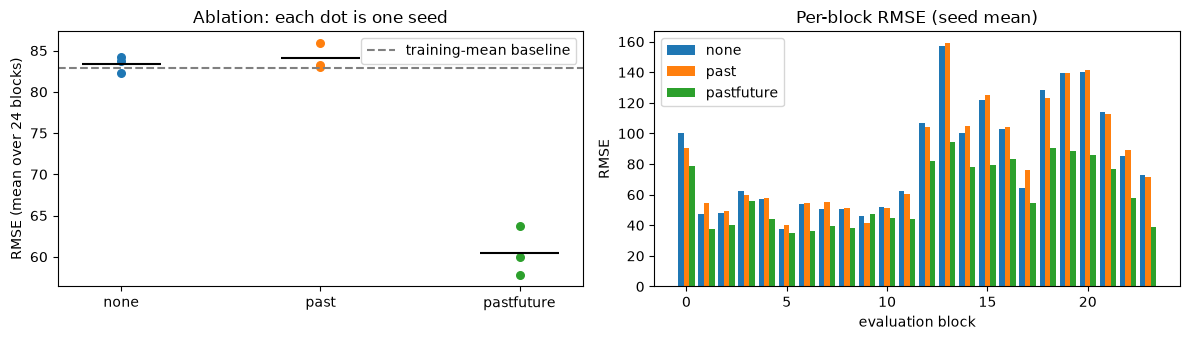

In [33]:
def block_rmse(v):  # shape (seeds, blocks)
    return np.array([[b["RMSE"] for b in runs[(v, s)]["blocks"]] for s in SEEDS])
for a, b in [("past", "none"), ("pastfuture", "none"), ("pastfuture", "past")]:
    d = block_rmse(a).mean(0) - block_rmse(b).mean(0)
    se = d.std(ddof=1) / np.sqrt(len(d))
    print(f"{a:10s} vs {b:5s}: mean ΔRMSE = {d.mean():6.2f}  (±{1.96*se:.2f}, 95% CI over blocks)  "
          f"{a} better on {int((d < 0).sum())}/24 blocks")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
for i, v in enumerate(VARIANTS):
    vals = per_seed[per_seed.variant == v].RMSE
    ax[0].scatter([i] * len(vals), vals, s=30); ax[0].hlines(vals.mean(), i - .2, i + .2, color="k")
ax[0].axhline(base["Training mean"]["RMSE"], ls="--", c="gray", label="training-mean baseline")
ax[0].set_xticks(range(3), VARIANTS); ax[0].set_ylabel("RMSE (mean over 24 blocks)"); ax[0].legend()
ax[0].set_title("Ablation: each dot is one seed")
x = np.arange(24); w = 0.27
for i, v in enumerate(VARIANTS):
    ax[1].bar(x + (i - 1) * w, block_rmse(v).mean(0), w, label=v)
ax[1].set_xlabel("evaluation block"); ax[1].set_ylabel("RMSE"); ax[1].legend(); ax[1].set_title("Per-block RMSE (seed mean)")
plt.tight_layout(); plt.savefig(f"{FIG}/2.3-ablation.pdf"); plt.show()

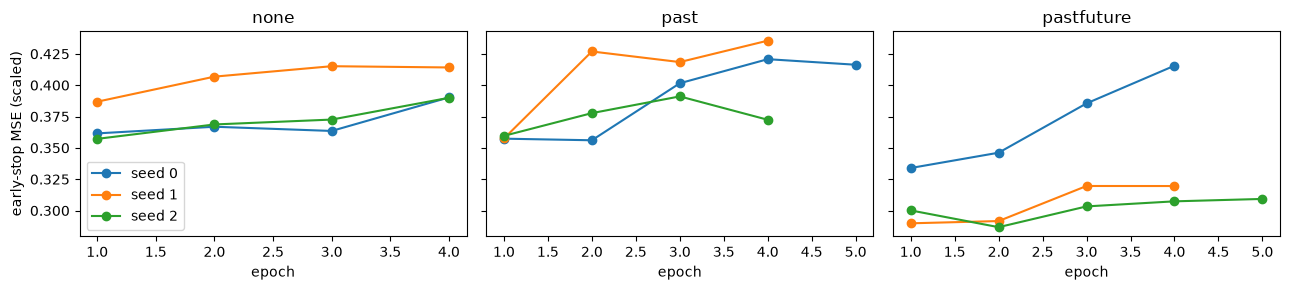

In [34]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
for i, v in enumerate(VARIANTS):
    for s in SEEDS:
        h = runs[(v, s)]["history"]
        ax[i].plot([r["epoch"] for r in h], [r["es_loss"] for r in h], marker="o", label=f"seed {s}")
    ax[i].set_title(v); ax[i].set_xlabel("epoch")
ax[0].set_ylabel("early-stop MSE (scaled)"); ax[0].legend()
plt.tight_layout(); plt.savefig(f"{FIG}/2.4-curves.pdf"); plt.show()

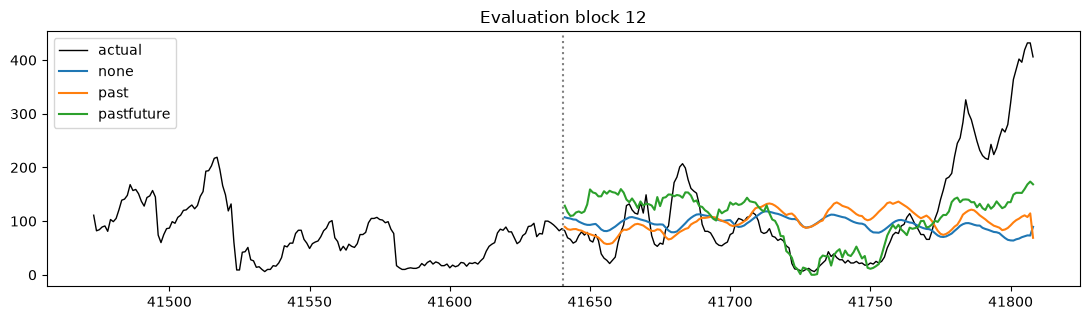

In [35]:
# A typical evaluation block: truth vs the three variants (seed 0)
k = 12; o = EVAL_ORIGINS[k]; tt = np.arange(o - 168, o + 168) + 1
plt.figure(figsize=(11, 3.3))
plt.plot(tt, y[o - 168:o + 168], c="k", lw=1, label="actual")
for v in VARIANTS:
    plt.plot(np.arange(o, o + 168) + 1, runs[(v, 0)]["preds"][k], label=v)
plt.axvline(o + 0.5, c="gray", ls=":"); plt.legend(); plt.title(f"Evaluation block {k}")
plt.tight_layout(); plt.savefig(f"{FIG}/2.5-example-block.pdf"); plt.show()

### Would a seed ensemble pay for itself?
Averaging k models costs k× the parameters and the sum of their epochs on the leaderboard. The question is how much RMSE that buys on the evaluation blocks.

In [36]:
ens = np.mean([runs[("pastfuture", s)]["preds"] for s in SEEDS], axis=0)
e_agg, _ = block_metrics(ens, y, EVAL_ORIGINS)
single = per_seed[per_seed.variant == "pastfuture"]
print(f"single model : RMSE {single.RMSE.mean():.2f} ± {single.RMSE.std():.2f}   P = {single.P.iloc[0]:,}  E ≈ {single.epochs_run.mean():.0f}")
print(f"3-seed mean  : RMSE {e_agg['RMSE']:.2f}           P = {single.P.sum():,}  E = {single.epochs_run.sum()}")

single model : RMSE 60.50 ± 3.03   P = 22,224  E ≈ 4
3-seed mean  : RMSE 58.92           P = 66,672  E = 13


## 7. Final forecast
**Choices, each made on the evaluation evidence above and never on the leaderboard:**
* **Variant.** Use the variant with the lowest mean RMSE across seeds whose gap over the others is larger than the seed spread (see the ablation table and the paired block test). In the first round of experiments this was `pastfuture`.
* **A single model, seed 0, fixed in advance.** The seed is not chosen because it scored best. A 3-seed ensemble triples P and sums E. The ensemble cell shows what that buys, and a single model is the cheaper trade unless the gain is large.
* **No refit on the full history.** The submitted model is the early-stopped model itself, and it forecasts from the last 168 observed steps plus the external data over the horizon. A refit would have to be counted on top of the early-stopping epochs (PDF §2.7). The training region already spans more than four yearly cycles.
* **P and E.** P is the trainable-parameter count of this model. E is the number of epochs that run actually executed, *including* the patience epochs after the best one, because those epochs were spent producing the forecast. Both are printed by the cell below and saved to `results/submission_meta.json`.


In [37]:
FINAL_VARIANT, FINAL_SEED = "pastfuture", 0
final(FINAL_VARIANT, FINAL_SEED)
meta = json.load(open(os.path.join(RES, "submission_meta.json")))
sub = pd.read_csv(os.path.join(RES, "submission_forecast.csv"))
assert len(sub) == 168 and sub.time_idx.iloc[0] == 43657 and sub.time_idx.iloc[-1] == 43824
print("Declare on the leaderboard ->  P =", meta["P"], "  E =", meta["E"])

{'variant': 'pastfuture', 'seed': 0, 'P': 22224, 'E': 4}
41.27, 39.03, 31.68, 42.81, 35.74, 43.96, 60.02, 57.54, 62.27, 53.45, 54.71, 63.39, 67.39, 59.27, 61.57, 61.57, 77.24, 91.73, 103.83, 119.72, 119.94, 118.22, 118.92, 124.73, 127.95, 128.74, 134.82, 137.63, 127.85, 127.13, 127.19, 127.47, 148.79, 155.75, 163.55, 171.25, 165.54, 162.02, 166.07, 167.39, 169.06, 178.47, 183.49, 185.70, 180.00, 183.58, 185.09, 175.65, 162.85, 147.98, 137.49, 125.42, 118.82, 120.07, 126.53, 127.01, 128.49, 140.85, 138.83, 121.72, 115.57, 131.93, 125.67, 122.74, 125.95, 124.58, 122.07, 123.39, 124.20, 126.66, 142.95, 131.61, 131.90, 126.59, 131.92, 119.13, 116.68, 113.02, 108.44, 109.89, 117.37, 118.72, 102.69, 84.67, 75.43, 73.36, 64.67, 59.01, 68.94, 75.17, 69.38, 70.12, 79.76, 87.44, 106.57, 121.26, 129.10, 126.57, 119.21, 117.82, 113.85, 113.36, 135.44, 143.75, 148.27, 151.46, 126.88, 116.95, 122.41, 106.61, 98.29, 89.66, 78.50, 74.09, 95.08, 108.80, 124.15, 115.21, 119.50, 123.96, 122.26, 117.00, 1

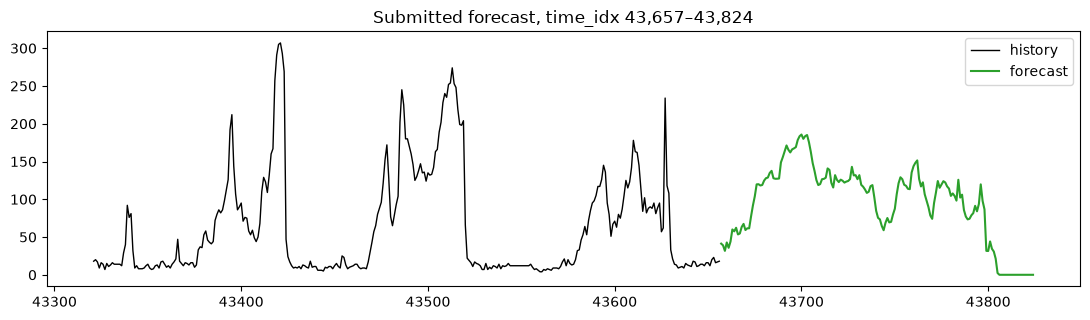

In [38]:
plt.figure(figsize=(11, 3.3))
plt.plot(np.arange(N_HIST - 336, N_HIST) + 1, y[-336:], c="k", lw=1, label="history")
plt.plot(sub.time_idx, sub.value, c="C2", label="forecast")
plt.legend(); plt.title("Submitted forecast, time_idx 43,657–43,824")
plt.tight_layout(); plt.savefig(f"{FIG}/2.6-forecast.pdf"); plt.show()